# Анализ рынка общественного питания Москвы

- Автор: Десислава Макеева

## Цели и задачи проекта

В рамках проекта необходимо было провести анализ рынка общественного питания Москвы:
- провести предобработку датасета с информацией о заведениях общественного питания Москвы и подготовить данные для дальнейшего исследования
- проанализировать распределение заведений общественного питания Москвы по категориям, расположению, количеству посадочных мест
- подсчитать соотношение сетевых и несетевых заведений
- проанализировать наличие корреляции между характеристиками заведений
- проанализировать вариацию среднего чека заведения в зависимости от его расположения
- определить топ-15 наиболее популярных сетевых ресторанов Москвы и их рейтинг
- определить среднюю стоимость чашки каппучино в разных районах и заведениях разных категорий

### Описание данных

<font color='#777778'> </font> 
Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Датасет содержит следующие столбцы:
- `name` — название заведения;
- `address` — адрес заведения;
- `district`— административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
0 — заведение не является сетевым;
1 — заведение является сетевым.
- `seats` — количество посадочных мест.
Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:


### Содержимое проекта
Проект содержит 4 основных раздела: 

* Загрузка данных и их описание
* Предобработка данных
* Анализ датасета и решение задач
* Итоговый вывод и рекомендации

---

##  Загрузка данных и их описание


In [6]:
!pip install phik -q
!pip install missingno -q
import phik
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from phik import phik_matrix

In [8]:
rest_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [9]:
rest_df.head(3)

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0


In [10]:
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация про кафе и рестораны Москвы.

После первичного анализа данных можно сделать следующие выводы:
- Данные в столбцах `rating`, `chain` и `seats` содержат числовые значения. Тип данных значений `rating` оптимален, тип данных значений `chain`, которые могут быть только  0 или 1, можно оптимизировать до `int8`; значения столбца `seats` могут принимать только целочисленные значения, поэтому после обработки пропусков их тип данных может быть оптимизирован до `int64`. Значения в остальных столбцах имеют тип данных `object` и хранят строковые данные.
- Пропуски содержатся только в столбцах `hours` и `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [12]:
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [13]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация ценовых характеристиках заведений.

После первичного анализа данных можно сделать следующие выводы:
- Инфомация с ценовыми характеристиками представлена меньше, чем для половины заведений
- Представленные данные содержат строковые или числовые значения и хранятся в типах данных `object` или `float64`. Типы данных для  всех столбцов соответствуют их значениям и не требуют оптимизации.
- Пропуски содержатся во всех столбцах в разной степени, хуже всего представлены данные о цене чашки каппучино: такая информация указана для только для 535 кафе. 

### Подготовка единого датафрейма

- Объединение двух датасетов в один датасет `df`, с которым будет продолжена работа дальше:

In [16]:
df = rest_df.merge(price_df, how = 'left', on='id')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


---

### Резюме по предоставленным данным

- Полный датасет с информацией о ресторанах и заведениях Москвы включает 13 столбцов и 8405 строк.
- Данные с описанием время работы, категорией и рейтингом заведения описаны полно, столбцы с информацией о ценовой категории заведения заполнены данными менее, чем на половину.
- Названия столбцов адекватны и не требуют изменений
- Столбцы, заполненные числовыми данными имеют числовой тип данных, но некоторые могут быть оптимизированы: тип данных столбца `chain` может быть оптимизирован от `int64` до `int8`, тип данных столбца `seats` может быть оптимизирован до `int64` после обработки пропусков. Остальные данные не требуют изменения типа. 
- Пропуски содержат столбцы `hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. 

## 2. Предобработка данных

### Оптимизация типов данных
Подготовка данных к исследовательскому анализу:

- Оптимизация типа данных столбца `chain`.

In [20]:
df['chain'] = pd.to_numeric(df['chain'], downcast = 'integer')

In [21]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   int8
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

### Пропущенные значения

- Подсчет пропущенных значений в данных:

In [23]:
print('\nДоля пропущенных значений:\n', df.isna().mean(),'\nЧисло пропущенных значений:\n', df.isna().sum())


Доля пропущенных значений:
 id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64 
Число пропущенных значений:
 id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64


Смотрим корреляцию между пропусками в разных столбцах:

<Axes: >

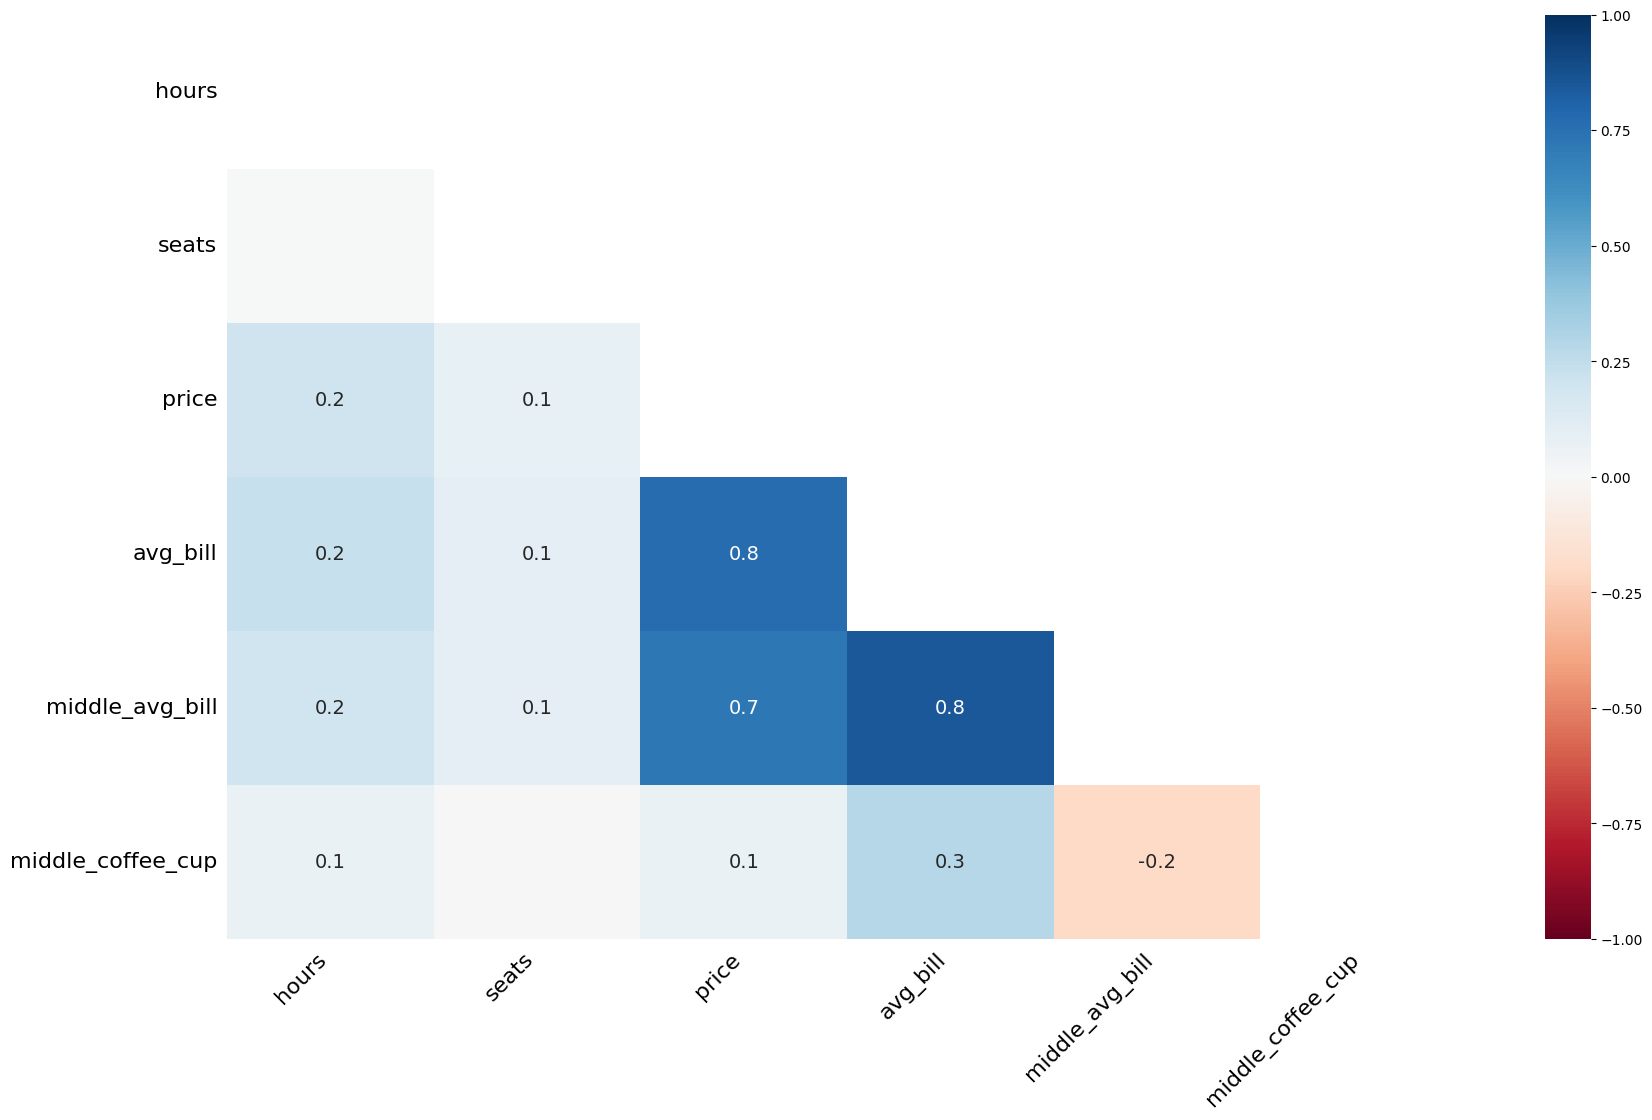

In [25]:
msno.heatmap(df)

Видно, наличие пропущенных значений в столбцах  `hours` имеет небольшую положительную корреляцию с отсутствием данных в столбцах `price`, `avg_bill`, `middle_avg_bill`. По-видимому, проблема в заведениях, для которых по всем параметрам предоставлено мало информации. Действительно, из 536 заведений с пропущенными значениями часов работы, данные по ценовым характеристикам предоставлены, менее, чем для 10 из них: 

In [27]:
df[df['hours'].isna()].count()

id                   536
name                 536
category             536
address              536
district             536
hours                  0
rating               536
chain                536
seats                300
price                  5
avg_bill               8
middle_avg_bill        6
middle_coffee_cup      1
dtype: int64

In [28]:
df_hoursna = df[df['hours'].isna()].groupby('category')['name'].count().sort_values()
display('Категории заведения в данных с пропущенными значениями часов работы:', df_hoursna)

'Категории заведения в данных с пропущенными значениями часов работы:'

category
пиццерия             5
булочная             7
столовая             9
кофейня             15
бар,паб             18
быстрое питание     33
ресторан            74
кафе               375
Name: name, dtype: int64

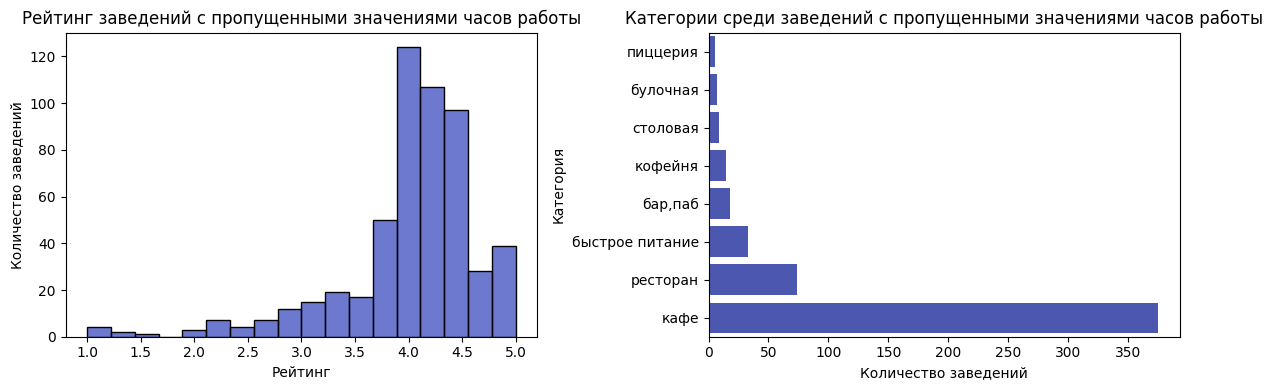

In [29]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
sns.histplot(data = df[df['hours'].isna()]['rating'], bins = 18, color = '#3b4cc0', ax = axes[0] )
sns.barplot( y = df_hoursna.index ,x = df_hoursna.values, color = '#3b4cc0', ax = axes[1] )

axes[0].set_title('Рейтинг заведений с пропущенными значениями часов работы')
axes[0].set_ylabel('Количество заведений')
axes[0].set_xlabel('Рейтинг')

axes[1].set_title('Категории среди заведений с пропущенными значениями часов работы')
axes[1].set_xlabel('Количество заведений')
axes[1].set_ylabel('Категория')

plt.tight_layout()
plt.show()

Пропущенные значения в графе `hours` в целом не связаны с каким-то конкретным рейтингом заведения: распределение рейтинга среди заведений с пропущенными значениями похоже распределение рейтинга среди всех заведений. А вот подавляющее большинство заведений, 70% заведений с пропусками в `hours` принадлежат категории 'кафе'. По всей видимости, в целом для этой категории характерно большое количество плохо заполненных данных информационной карточки на Яндекс Картах.<br>
Смотрим долю пропущенных значений для разных категорий, чтобы понять, нет ли среди категорий таких, для которых характерны пропуски в каких-либо столбцах:

In [31]:
df_subset = df.groupby('category')[['name','hours','seats','price','avg_bill', 'middle_avg_bill','middle_coffee_cup']].count().reset_index()
df_subset = df_subset.rename(columns = {'name': 'names_count'})
for col in ['hours','seats','price','avg_bill','middle_avg_bill','middle_coffee_cup']:
    df_subset[col] = (df_subset['names_count'] - df_subset[col])/df_subset['names_count'] #считаем долю пропущенных значений для каждой категории
display(df_subset) #Процент пропущенных значений в столбцах seats, price, avg_bill для разных категорий

,category,names_count,hours,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,"бар,паб",765,0.023529,0.388235,0.354248,0.366013,0.543791,0.992157
1,булочная,256,0.027344,0.421875,0.839844,0.792969,0.792969,1.000000
2,быстрое питание,603,0.054726,0.421227,0.684909,0.605307,0.606965,0.998342
3,кафе,2378,0.157696,0.487805,0.733810,0.706476,0.708158,0.998318
4,кофейня,1413,0.010616,0.468507,0.663128,0.489738,0.858457,0.631281
5,пиццерия,633,0.007899,0.325434,0.508689,0.368088,0.375987,0.995261
6,ресторан,2043,0.036221,0.378365,0.502203,0.490945,0.490945,1.000000
7,столовая,315,0.028571,0.479365,0.514286,0.425397,0.425397,1.000000


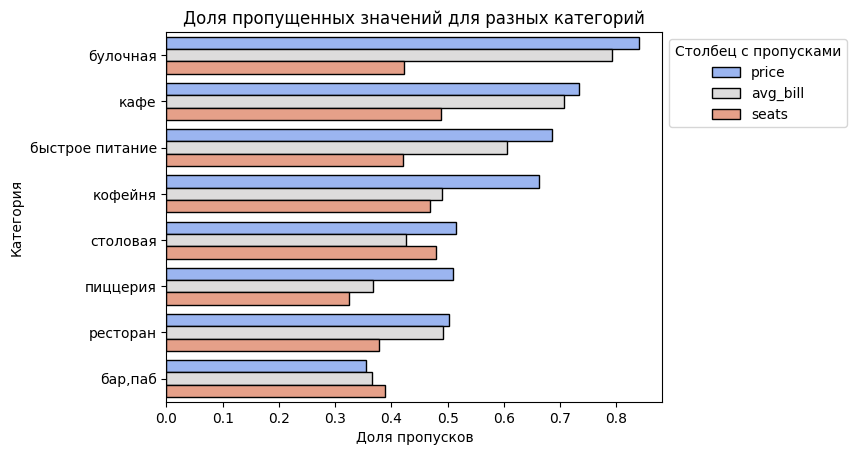

In [32]:
df_long = pd.melt(df_subset, id_vars=['category'], value_vars=['seats', 'price', 'avg_bill'],
                  var_name='column_isna', value_name='isna_ratio').sort_values(by = 'isna_ratio',ascending  = False)

sns.barplot(data=df_long, hue ='column_isna', x='isna_ratio', y ='category', palette = 'coolwarm', edgecolor = 'k')
plt.legend(title = 'Столбец с пропусками', loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Доля пропусков')
plt.ylabel('Категория')
plt.title('Доля пропущенных значений для разных категорий')
plt.show()

- Большой процент пропусков значений `price`  и `avg_bills` характерен больше всего для булочных и кафе.
- Пропуски значений `seats` от категории не сильно зависят, немного лучше, по сравнению с остальными категориями, количество мест заполнено для пиццерий.
- Из всех категорий, лучше всего информация по `avg_bills` и `price` заполнена для баров - пропусков значений меньше 40%.

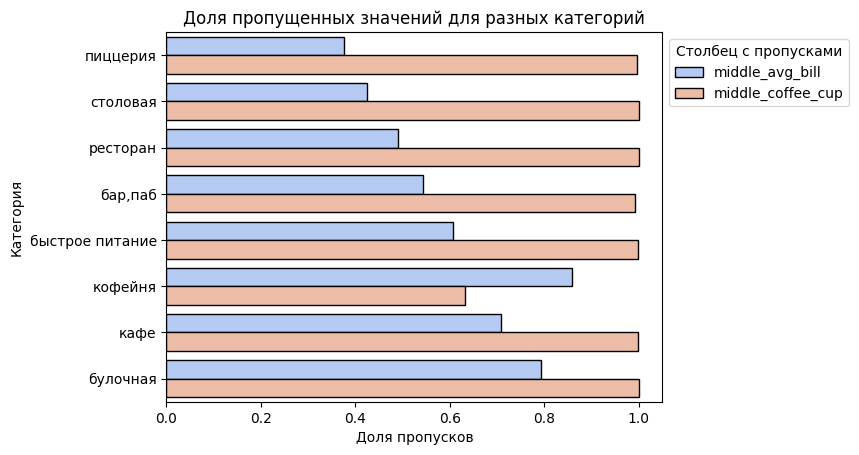

In [34]:
df_long2 = pd.melt(df_subset, id_vars=['category'], value_vars=['middle_avg_bill','middle_coffee_cup'],
                  var_name='column_isna', value_name='isna_ratio').sort_values(by = 'isna_ratio',ascending  = True)

sns.barplot(data=df_long2, hue ='column_isna', x='isna_ratio', y ='category', palette = 'coolwarm', 
            edgecolor = 'k')
plt.legend(title = 'Столбец с пропусками', loc='upper left', bbox_to_anchor=(1, 1))

plt.xlabel('Доля пропусков')
plt.ylabel('Категория')
plt.title('Доля пропущенных значений для разных категорий')
plt.show()

- Данные `middle_coffee_cup` указаны почти исключительно для кофеен.
- Данные `middle_avg_bill` лучше всего указаны для пиццерий и столовых, хуже всего - для булочных и кафе, видимо, для которых в целом понятие 'среднего чека' не очень характерно

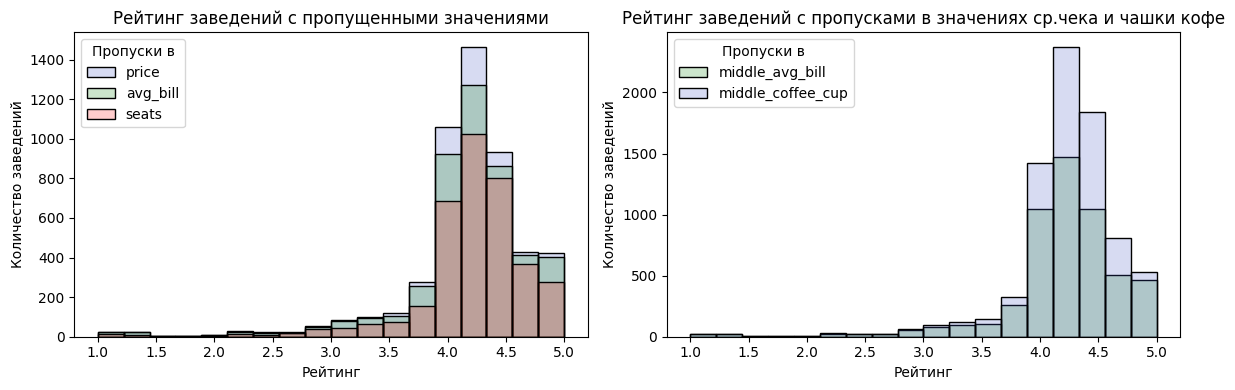

In [36]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
sns.histplot(data = df[df['price'].isna()]['rating'], bins = 18, color = '#3b4cc0', ax = axes[0], alpha = 0.2 )
sns.histplot(data = df[df['avg_bill'].isna()]['rating'], bins = 18, color = 'green', ax = axes[0], alpha = 0.2)
sns.histplot(data = df[df['seats'].isna()]['rating'], bins = 18, ax = axes[0], label = 'seats', color = 'red', alpha = 0.2)

axes[0].set_title('Рейтинг заведений с пропущенными значениями')
axes[0].set_ylabel('Количество заведений')
axes[0].set_xlabel('Рейтинг')
axes[0].legend( ['price', 'avg_bill', 'seats'], title='Пропуски в')

sns.histplot(data = df[df['middle_avg_bill'].isna()]['rating'], bins = 18, color = 'green', ax = axes[1], alpha = 0.2 )
sns.histplot(data = df[df['middle_coffee_cup'].isna()]['rating'], bins = 18, color = '#3b4cc0', ax = axes[1], alpha = 0.2)
axes[1].legend( ['middle_avg_bill', 'middle_coffee_cup'], title='Пропуски в')

axes[1].set_title('Рейтинг заведений с пропусками в значениях ср.чека и чашки кофе')
axes[1].set_xlabel('Рейтинг')
axes[1].set_ylabel('Количество заведений')

plt.tight_layout()
plt.show()

Пропущенные значения в столбцах не связаны с определенным рейтингом заведений - распределение пропусков в зависимости от рейтинга заведения в целом схоже с распределением рейтинга для всех заведений (это распределение было сделано в главе 3.5). 

 - Пропуски в столбце `hours` (6.4%) заменяем на строку `Нет информации`:

In [39]:
df['hours'] = df['hours'].fillna('Нет информации')

- Пропуски в числовых данных решила оставить как есть, т.к. пропусков много и отбрасывать много данных не хочется, а "заглушки" пропусков помешают в рассчетах по этим данным.

### Неявные дубликаты

In [42]:
print('Уникальные значения в столбцах до обработки:\n', df.nunique())

Уникальные значения в столбцах до обработки:
 id                   8406
name                 5614
category                8
address              5753
district                9
hours                1307
rating                 41
chain                   2
seats                 229
price                   4
avg_bill              897
middle_avg_bill       230
middle_coffee_cup      96
dtype: int64


- Нормализация данных в столбцах `name` и `address`:

In [44]:
names_num = df['name'].nunique()
addr_num = df['address'].nunique()

In [45]:
df['name'] = df['name'].str.lower()
df['address'] = df['address'].str.lower()
df['name'] = df['name'].str.replace('’', "'")

In [46]:
print(f"Уникальных названий до обработки: {names_num}, после нормализации: {df['name'].nunique()}. Обработано неявных дубликатов:{names_num - df['name'].nunique()}")
print(f"Уникальных адресов до обработки: {addr_num}, после нормализации: {df['address'].nunique()}. Обработано неявных дубликатов:{addr_num - df['address'].nunique()}")

Уникальных названий до обработки: 5614, после нормализации: 5511. Обработано неявных дубликатов:103
Уникальных адресов до обработки: 5753, после нормализации: 5752. Обработано неявных дубликатов:1


Анализ данных в столбце с названиями кафе показал, что данные содержат неявно дублирующиеся названия - это руссифицированные названия кафе (как 'стардогс' и 'stardogs'), синонимы (например, jeffrey's coffeeshop и  jeffrey's coffee являются кафе одной сети),  опечатки и разное использование символов ('доминос' и 'домино'c', 'стардогс' и 'стардог', 'кебаб-хауз' и 'кебаб хауз' и т.д.). Вся вариабельность названий имеет очень разную природу, и одним универсальным подходом избавиться от этих дубликатов не получается. Оставила эти данные как есть, так как кажется неправильным избавляться от части неявных дубликатов вручную, а чтобы все данные обработать, нужны какие-то нестандартные подходы. <br>
Второе, на что обратила внимание, что значение `chain` очень сильно зависит от неявных дубликатов (видимо, заполнялось, автоматически, если название дублировалось) и часто в случае с неявными дубликатами `chain` = 0, хотя кафе на самом деле является сетевым. Если мы верим, что определение `chain` так и происходило, то  после обработки дубликатов нужно заново определить `chain` для кафе, чтобы убрать ложно-отрицательные значения.

Пример-иллюстрация неявных дубликатов в данных для кафе 'стардогс': кафе названо тремя разными способами, категория отличается для одного кафе из выборки и неявные дубликаты не отмечены как сетевые кафе (имеют `chain` = 0)

In [49]:
display(df[(df['name'].str.contains('стардог'))|(df['name'].str.contains('stardog'))])

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1225,de175c2ae93840bb9ca9b348a54f4655,стардогс,быстрое питание,"москва, улица твардовского, 8к5",Северо-Западный административный округ,пн-сб 08:00–20:00,4.0,1,NaN,низкие,Средний счёт:150–200 ₽,175.0,NaN
2923,4930defe02e44581806038b6917e21de,stardogs,быстрое питание,"москва, щёлковское шоссе, 100к100",Восточный административный округ,"ежедневно, 10:00–22:00",3.7,0,NaN,NaN,Средний счёт:149–249 ₽,199.0,NaN
3350,beab398f86dd48f69f3d2785324c6eaf,стардогс,быстрое питание,"москва, западный административный округ, район...",Западный административный округ,"ежедневно, 10:00–22:00",4.0,1,NaN,NaN,NaN,NaN,NaN
5582,3bcf8a3e0a3d40828717b73e9a0988ac,стардог,кафе,"москва, парк радуга",Восточный административный округ,"ежедневно, 10:00–20:00",4.8,0,NaN,NaN,NaN,NaN,NaN
6129,86d4185884fb4f7d835e0c307f0416da,стардогс,быстрое питание,"москва, улица вавилова, 15",Юго-Западный административный округ,"ежедневно, круглосуточно",3.9,1,12.0,NaN,NaN,NaN,NaN


Уникальные значения в столбцах `category`, `district` и `price` с небольшим количеством категорий:

In [51]:
print( np.sort(df['category'].unique()))

['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']


In [52]:
print( np.sort(df['district'].unique()))

['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']


In [53]:
print(df['price'].unique())

[nan 'выше среднего' 'средние' 'высокие' 'низкие']


В остальных столбцах неявные дубликаты также не обнаружены.

### Явные дубликаты

In [56]:
print('Полностью дублирующихся строк в датасете: ', df.duplicated().sum())

Полностью дублирующихся строк в датасете:  0


Пара 'название кафе'-'адрес кафе'  уникально указывает на заведение, поэтому ищем строки с дублирующимися парами `name` - `address`:

In [58]:
display(df[df.duplicated(subset=['name','address',], keep = False)])

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,Нет информации,4.1,0,276.0,NaN,NaN,NaN,NaN


Нашлось 4 пары почти полностью дублирующихся строк: информация отличается в столбах `hours`, `category`, `chain`. Более поздние дублирующиеся записи скорее всего имеют более актуальные данные по кафе, поэтому для всех кафе можно сохранить вторую строчку с информацией и, если в более поздних строках информация по какому-то столбцу отсутствует, заполнить ее из более ранней строки. В результате:
* `кафе` - в датасете остается вторая строка
* `more poke` - в датасете остается вторая строка с chain = 1
* `раковарня клешни и хвосты` - в датасете остается вторая строка
* `хлеб да выпечка` - расписание указано только в первой строке, поэтому оставляю вторую строку и записываю туда расписание из первой.

In [60]:
rows_old = df.shape[0]
df = df.drop_duplicates(subset = ['name','address'], keep = 'last') 
df = df.reset_index(drop = True)
df.loc[(df['name'] == 'хлеб да выпечка')&(df['address'].str.contains('ярцевская')), 'hours'] = 'ежедневно, 09:00–22:00'
print(f'Строк до удаления дубликатов: {rows_old}, после удаления: {df.shape[0]}.')
#print(df.loc[(df['name'] == 'more poke')|(df['name'] == 'раковарня клешни и хвосты')|(df['name'] == 'хлеб да выпечка')]) #проверка, что остались корректные строки

Строк до удаления дубликатов: 8406, после удаления: 8402.


- Для дальнейшей работы создаем столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [62]:
df['is_24_7'] = (df['hours'].str.contains('ежедневно'))&(df['hours'].str.contains('круглосуточно'))

---

### Резюме по предобработке данных

- Тип данных столбца `chain` был оптимизирован до `int8`
- ребуют изменения типа. 
- Пропуски в столбцах `hours` были заменены на строк `Нет информации`, пропуски в столбцах `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` были оставлены без изменений
- В результате нормализации названий заведений и адреса заведений были выявлены 104 неявно дублирующиеся строки
- В данных также были обнаружены и обработаны 4 явно дублирующиеся строки

## Анализ датасета заведений по требуемым параметрам. Визуализации результатов

---

### Распределение заведений по категориям

In [66]:
print('Количество заведений в каждой категории:\n', df['category'].value_counts())

Количество заведений в каждой категории:
 category
кафе               2377
ресторан           2041
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            255
Name: count, dtype: int64


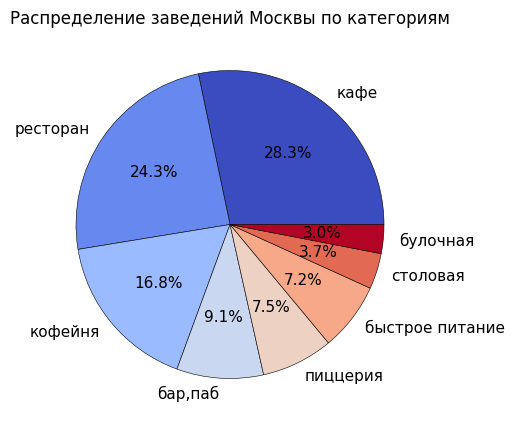

In [67]:
plt.figure(figsize = (5,5))
df['category'].value_counts().plot(kind = 'pie', 
                                colormap = 'coolwarm', 
                                label = '', 
                                autopct='%.1f%%',
                                wedgeprops={'edgecolor': 'black', 'linewidth': 0.4},
                                textprops={ 'fontsize': 11}
                               )
#plt.axis('equal')  # Обеспечение круговой диаграммы
plt.title('Распределение заведений Москвы по категориям')
plt.show()

Чаще всего среди заведений общественного питания Москвы встречаются кафе (28,3%) или рестораны (24,3%). Меньше всего всего в Москве представлены булочные (3%) и столовые (3,7%).

---

### Распределение заведений по районам Москвы

In [70]:
district_map = {
    'Северный административный округ': 'САО',
    'Северо-Восточный административный округ': 'СВАО',
    'Северо-Западный административный округ': 'СЗАО',
    'Западный административный округ': 'ЗАО',
    'Центральный административный округ': 'ЦАО',
    'Восточный административный округ': 'ВАО',
    'Юго-Восточный административный округ': 'ЮВАО',
    'Южный административный округ': 'ЮАО',
    'Юго-Западный административный округ': 'ЮЗАО'
}
df['district_short'] = df['district'].map(district_map)
print ('Количество заведений по административным округам Москвы:')
df['district_short'].value_counts()

Количество заведений по административным округам Москвы:


district_short
ЦАО     2242
САО      898
ЮАО      892
СВАО     890
ЗАО      850
ВАО      798
ЮВАО     714
ЮЗАО     709
СЗАО     409
Name: count, dtype: int64

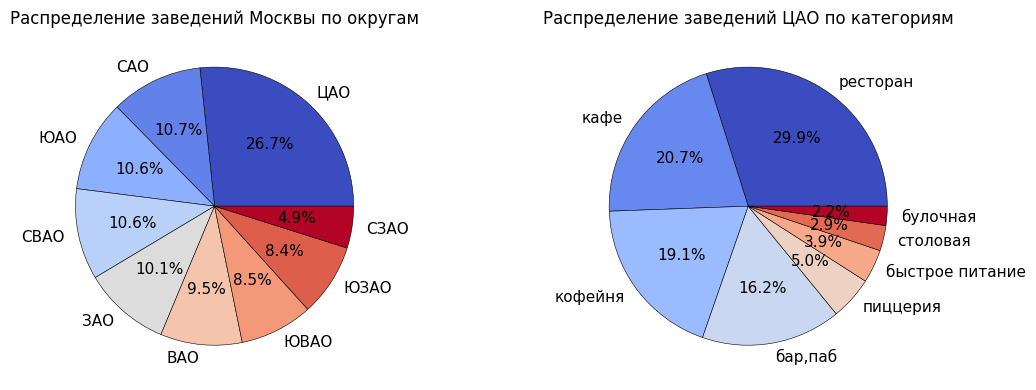

In [71]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

df['district_short'].value_counts().plot(kind = 'pie', 
                                colormap = 'coolwarm', 
                                label = '', 
                                autopct='%.1f%%',
                                wedgeprops={'edgecolor': 'black', 'linewidth': 0.4},
                                textprops={ 'fontsize': 11},
                                ax = axes[0]
                               )
df[df['district_short'] == 'ЦАО'].groupby('category')['name'].count().sort_values(ascending = False).plot(kind = 'pie', 
                                colormap = 'coolwarm', 
                                label = '', 
                                autopct='%.1f%%',
                                wedgeprops={'edgecolor': 'black', 'linewidth': 0.4},
                                textprops={ 'fontsize': 11},
                                ax = axes[1]
                               )

#plt.axis('equal')  # Обеспечение круговой диаграммы
axes[0].set_title('Распределение заведений Москвы по округам')
axes[1].set_title('Распределение заведений ЦАО по категориям')

plt.tight_layout()
plt.show()

Ожидаемо, больше всего заведений Москвы сосредоточено в Центральном административном округе (26,7%). Кажется интересным, что в СЗАО самое маленькое количество заведений. При этом в СЗАО есть ряд престижных районов (например, Строгино, Хорошево-Мневники) с высокой плотностью застройки и платежеспособным населением. Возможно, СЗАО и ЮЗАО, в котором тоже мало заведений общественного питания, имеют недостаток заведений. <br>
Среди заведений в центре Москвы чаще всего встречаются рестораны (29,9%), реже всего булочные и столовые.

---

### Cоотношение сетевых и несетевых заведений


Смотрим на количество несетевых и сетевыз заведений в разных категориях в абсолютных значениях, а также в процентном соотношении:

In [75]:
pivot_chain = pd.pivot_table(df, index = 'category', columns = 'chain', values = 'name',  aggfunc = 'count', margins = True).sort_values(by = [1][0], ascending = False)
print('Количество несетевых и сетевых заведений в разных категориях:')
display(pivot_chain)

Количество несетевых и сетевых заведений в разных категориях:


chain,0,1,All
category,,,
All,5198,3204,8402
кафе,1598,779,2377
ресторан,1311,730,2041
кофейня,693,720,1413
пиццерия,303,330,633
быстрое питание,371,232,603
"бар,паб",596,169,765
булочная,99,156,255
столовая,227,88,315


In [76]:
print('Доля сетевых заведений в разных категориях:')
df.groupby('category').agg({'chain':'mean'}).round(2).sort_values(by='chain', ascending = False)

Доля сетевых заведений в разных категориях:


,chain
category,
булочная,0.61
пиццерия,0.52
кофейня,0.51
быстрое питание,0.38
ресторан,0.36
кафе,0.33
столовая,0.28
"бар,паб",0.22


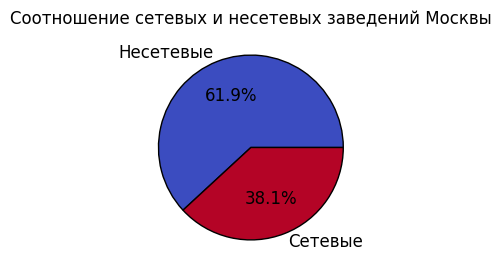

In [77]:
plt.figure(figsize=(3, 3))
df['chain'].value_counts().plot(kind = 'pie', 
                                colormap = 'coolwarm', 
                                label = '', 
                                labels = ['Несетевые', 'Сетевые'], 
                                autopct='%.1f%%',
                                wedgeprops={'edgecolor': 'black', 'linewidth': 1},
                                textprops={ 'fontsize': 12}
                               )
#plt.axis('equal')  # Обеспечение круговой диаграммы
plt.title('Соотношение сетевых и несетевых заведений Москвы')
plt.show()

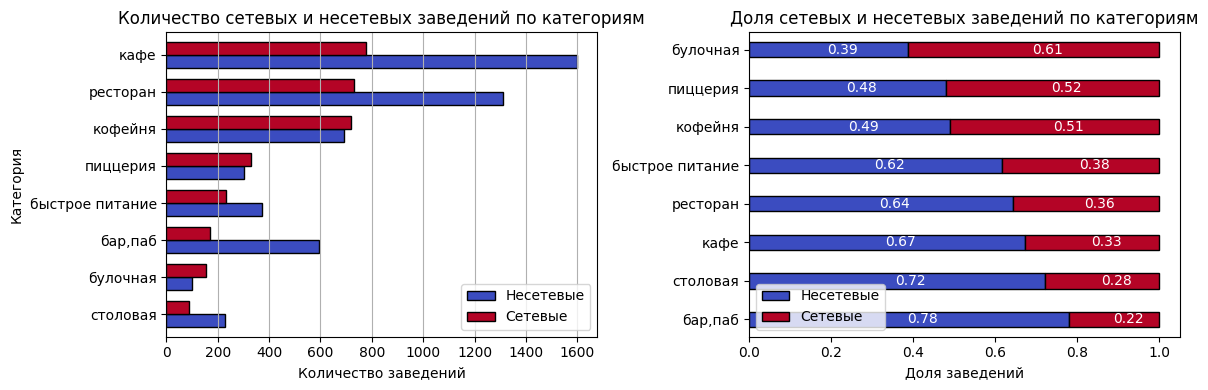

In [78]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
df_unstack = df.groupby('category')['chain'].value_counts().unstack(fill_value = 0).sort_values(by = [1], ascending = True)
plot1 = df_unstack.plot(kind='barh', 
                        rot =0, 
                        colormap = 'coolwarm', 
                        edgecolor = 'k',
                        width = 0.7,
                        ax = axes[0])
axes[0].set_title('Количество сетевых и несетевых заведений по категориям')
axes[0].set_ylabel('Категория')
axes[0].set_xlabel('Количество заведений')
axes[0].legend(['Несетевые','Сетевые'], title = '', loc = 'best')
axes[0].grid(axis = 'x')

df.groupby('category')['chain'].value_counts(normalize = True).unstack(fill_value = 0).sort_values(by = [1]).plot(kind='barh', 
                                                                                            stacked = True, 
                                                                                            colormap = 'coolwarm',
                                                                                            width = 0.4,
                                                                                            edgecolor = 'k',
                                                                                            ax = axes[1],
                                                                                            ylabel = '')
axes[1].set_title('Доля сетевых и несетевых заведений по категориям')
axes[1].set_xlabel('Доля заведений')
axes[1].legend(['Несетевые','Сетевые'], title = '', loc = 'lower left')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt = '%.2f', label_type = 'center', padding = 10, color = 'w')
plt.tight_layout()
plt.show()

Из 8402 заведений, указанных в датасете, 3204 заведения (38,1%) являются сетевыми. 
- Самое большое количество сетевых заведений отмечено в категориях `кафе` (779 заведений), `ресторан` (730 заведений) и `кофейня` (720 заведений). Однако эти категории заведений являются и самыми представленными категориями в датасете.-
- Доля сетевых заведений в категориях `кафе` и  `ресторан` не является высокой: среди `кафе` только 33% заведений сетевые, а среди `ресторанов` - 36% сетевые.
- Чаще всего сетевые заведения встречаются в категориях `булочная` (61%), `пиццерия` (52%) и `кофейня` (51%). То есть категория `кофейня` входит как в топ-3 заведений с большим количеством сетевых заведений , так и в топ-3 с самой большой долей сетевых заведений.
- Самая маленькая доля сетевых заведений в категории `бар, паб` - 22% баров являются частью сети.
<br>
По всей видимости, кофейни, булочные и пиццерии предлагают относительно простые и унифицированные продукты, и данные заведения легко масштабировать. Это делает данные категории более подходящими для сетевого бизнеса. <br>
В категориях с высокой уникальностью и индивидуальностью (например, бары/пабы) доля сетевых заведений ниже. Это  может быть связано с тем, что такие заведения чаще ориентируются на локальную аудиторию и уникальные концепции.

---

### Количество посадочных мест в заведениях.

Среднее значение посадочных мест для заведений из датасета - 108.4, медиана - 75. Большое отличие между средним и медианой вместе с большим станд. отклонением(122.8) говорит о том, что в данных есть выбросы. Максимальное количество посадочных мест - 1288:

In [85]:
display(df['seats'].describe())

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Text(0.5, 0, 'Количество мест')

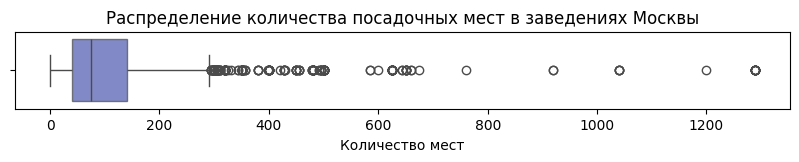

In [86]:
plt.figure(figsize=(10, 1))
boxplot_all = sns.boxplot(data = df, x = 'seats', showfliers = True,  color = '#3b4cc0',
                          boxprops=dict(alpha=0.7))
plt.title('Распределение количества посадочных мест в заведениях Москвы')
plt.xlabel('Количество мест')

Среди топ-заведений по количеству посадочных мест:
- у 11 заведений указано маскимальное количество посадочных мест - 1288, при этом среди них есть заведения из разной категорий и с разным средним чеком, но все они располагаются на проспекте Вернадского. Выглядит это так, что при внесении данных о количестве посадочных мест произошла какая-то ошибка и в `seats` был записан какой-то другой параметр.
- аналогично, 4 разных заведения по адресу "Измайловское шоссе, 71, корп.а"  якобы имеют по 1040 посадочных мест, что тоже очень похоже на ошибку. По-видимому, данные по количеству посадочных мест содержат много ошибок, и наблюдаемые сильные выбросы  являются результатом этих ошибок.

In [88]:
df[['name', 'category', 'address','seats','middle_avg_bill']].sort_values(by = 'seats', ascending = False).head(20)

,name,category,address,seats,middle_avg_bill
6637,one price coffee,кофейня,"москва, проспект вернадского, 84, стр. 1",1288.0,NaN
6520,ян примус,ресторан,"москва, проспект вернадского, 121, корп. 1",1288.0,1500.0
6680,пивной ресторан,"бар,паб","москва, проспект вернадского, 121, корп. 1",1288.0,NaN
6654,гудбар,"бар,паб","москва, проспект вернадского, 97, корп. 1",1288.0,700.0
6767,точка,кафе,"москва, проспект вернадского, 84, стр. 1",1288.0,NaN
6570,мюнгер,пиццерия,"москва, проспект вернадского, 97, корп. 1",1288.0,NaN
6686,японская кухня,ресторан,"москва, проспект вернадского, 121, корп. 1",1288.0,NaN
6834,alternative coffee,кофейня,"москва, проспект вернадского, 41, стр. 1",1288.0,NaN
6514,delonixcafe,ресторан,"москва, проспект вернадского, 94, корп. 1",1288.0,1750.0
6804,яндекс лавка,ресторан,"москва, проспект вернадского, 51, стр. 1",1288.0,NaN


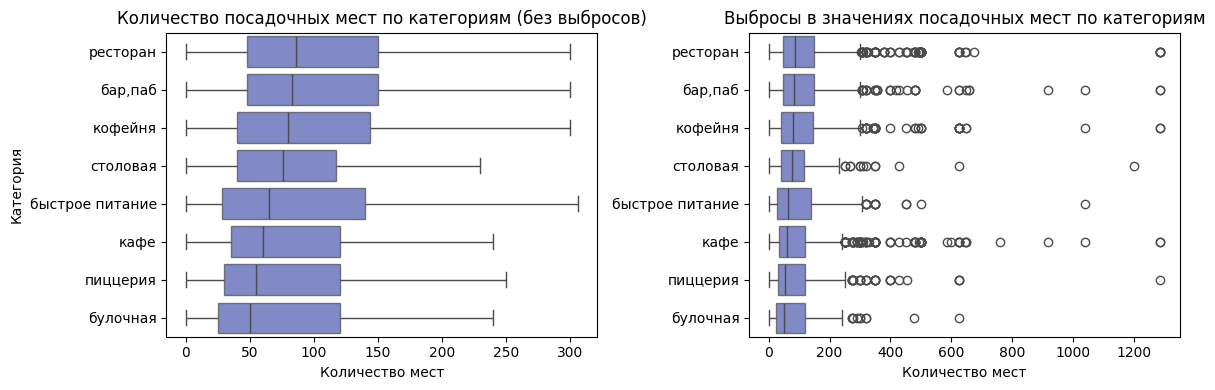

In [89]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

order = df.groupby('category')['seats'].median().sort_values(ascending = False).index
sns.boxplot(data = df, y = 'category', x = 'seats', order = order, showfliers = False, ax = axes[0], color = '#3b4cc0', boxprops=dict(alpha=0.7))
sns.boxplot(data = df, y = 'category', x = 'seats', order = order, showfliers = True, ax = axes[1], color = '#3b4cc0', boxprops=dict(alpha=0.7))
axes[0].set_title('Количество посадочных мест по категориям (без выбросов)')
axes[1].set_title('Выбросы в значениях посадочных мест по категориям')
axes[0].set_xlabel('Количество мест')
axes[1].set_xlabel('Количество мест')
axes[0].set_ylabel('Категория')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [90]:
df.groupby('category')['seats'].median().sort_values(ascending = False)

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

Распределение посадочных мест в разных категориях логичное: самое большое количество посадочных мест в ресторанах (медиана = 86), самое маленькое - в булочных (медиана = 50). Количество посадочных мест сильно варьируется внутри каждой категории, распределение значений смещено вправо, а также сильные выбросы значений содержатся почти во всех категориях. К тому же столбец `seats`, по-видимому, содержит ошибки, поэтому выводы на основании информации о количестве мест посадки стоит делать с осторожностью.

---

### Рейтинг заведений.


In [94]:
df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [95]:
print ('Средние рейтинги заведений по категориям: ')
df.groupby('category')['rating'].mean().sort_values(ascending = False)

Средние рейтинги заведений по категориям: 


category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290348
кофейня            4.277282
булочная           4.269020
столовая           4.211429
кафе               4.124274
быстрое питание    4.050249
Name: rating, dtype: float64

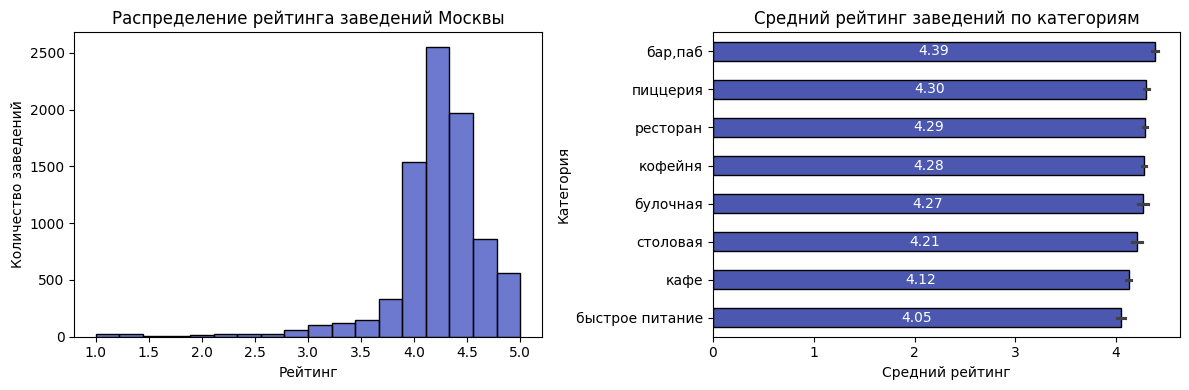

In [96]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
sns.histplot(data = df['rating'], bins = 18, color = '#3b4cc0', ax = axes[0] )

order = df.groupby('category')['rating'].mean().sort_values(ascending = False).index
sns.barplot(data = df, y = 'category', x = 'rating', order = order, ax = axes[1], color = '#3b4cc0', width = 0.5, edgecolor = 'k')
axes[0].set_title('Распределение рейтинга заведений Москвы')
axes[1].set_title('Средний рейтинг заведений по категориям')
axes[0].set_xlabel('Рейтинг')
axes[1].set_xlabel('Средний рейтинг')
axes[0].set_ylabel('Количество заведений')
axes[1].set_ylabel('Категория')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt = '%.2f',label_type = 'center', color = 'w')
plt.tight_layout()
plt.show()


Больше всего заведений из датасета имеют рейтинг 4.25, в целом средний рейтинг заведений варьируется не сильно: от 4.05 у заведений быстрого питания, до 4.39 у баров.

---

### Корреляция рейтинга заведения с другими данными датасета.

Матрица корреляции характеристик заведения: рейтинга, его категории, положения (административный район Москвы), статуса сетевого заведения, количества мест, ценовой категории и признака, является ли заведение круглосуточным.

interval columns not set, guessing: ['rating', 'chain', 'seats']


Text(0.5, 1.0, 'Тепловая карта корреляций данных заведений Москвы')

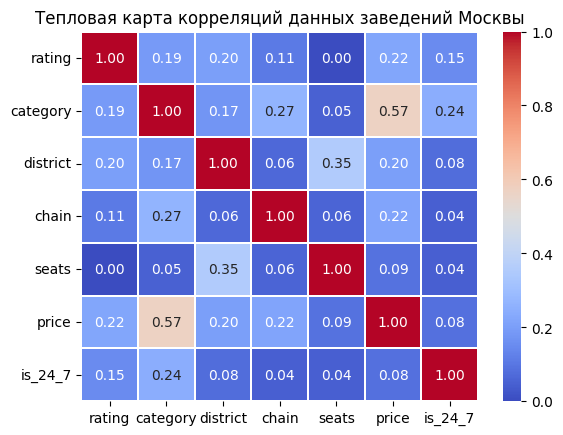

In [100]:
corr_matrix = df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()
sns.heatmap(corr_matrix, cmap = 'coolwarm', annot = True, fmt = '.2f', linewidths = 0.1)
plt.title('Тепловая карта корреляций данных заведений Москвы')

Данные рейтинга заведений имеют очень слабую корреляцию со всеми столбцами (0.0 - 0.22). Самое большое значение корреляции для данных рейтинга с ценовой категорией (`rating`- `price`, 0.22). Корреляционную связь имеет пара данных `price` - `category` - коэфф. корр. 0.57, и более слабую связь имеет пара `seats`-`district` (коэф.корр. 0.35).  Для этих трех пар построила дополнительные графики:

C:\Users\Деси\AppData\Local\Temp\ipykernel_25656\969679292.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 90)
C:\Users\Деси\AppData\Local\Temp\ipykernel_25656\969679292.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation = 90)


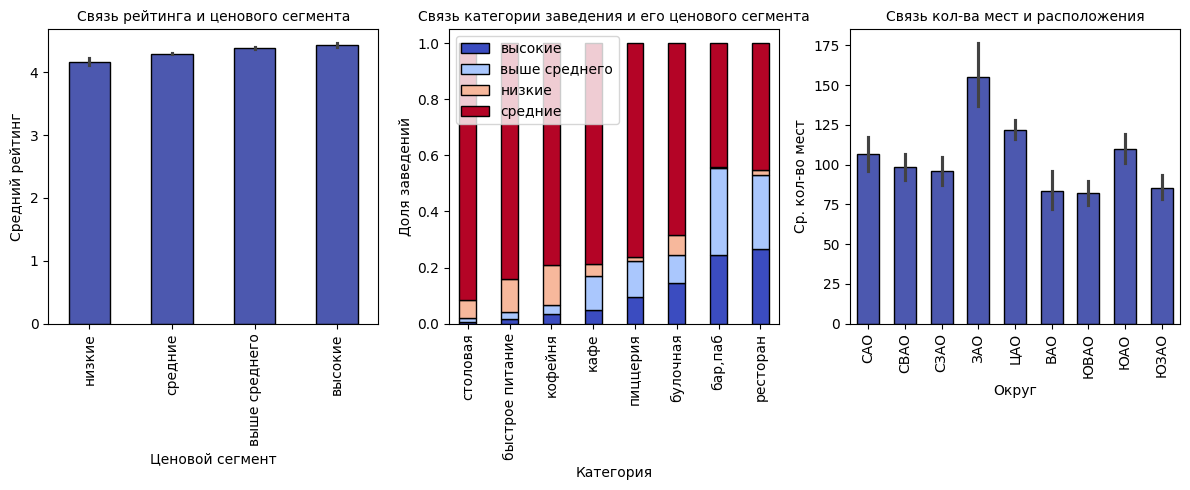

In [103]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12,5))
sns.barplot (data = df, x = 'price', y = 'rating', estimator = 'mean', ax = axes[0], 
             order = ['низкие', 'средние','выше среднего', 'высокие'], 
             color = '#3b4cc0', edgecolor = 'k', width = 0.5)
axes[0].set_title('Связь рейтинга и ценового сегмента', fontsize = 10)

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 90)
axes[0].set_xlabel('Ценовой сегмент')
axes[0].set_ylabel('Средний рейтинг')

df.groupby('category')['price'].value_counts(normalize = True).unstack(fill_value = 0).sort_values(by = ['высокие']).plot(kind='bar', 
                                                                                            stacked = True, 
                                                                                            colormap = 'coolwarm',
                                                                                            width = 0.4,
                                                                                            edgecolor = 'k',
                                                                                            ax = axes[1],
                                                                                            ylabel = '')
axes[1].legend(title = '', loc = 'upper left')
axes[1].set_title('Связь категории заведения и его ценового сегмента', fontsize = 10)
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Доля заведений')

sns.barplot(data = df, x = 'district_short', y = 'seats', estimator = 'mean', ax = axes[2], color = '#3b4cc0', width = 0.6, edgecolor = 'k')
axes[2].set_title ('Связь кол-ва мест и расположения', fontsize = 10)
axes[2].set_xlabel('Округ')
axes[2].set_ylabel('Ср. кол-во мест')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation = 90)

plt.tight_layout()
plt.show()

Можно отметить следующие корреляции:
- Заведения в более высоком ценовом сегменте имеют в среднем более высокий рейтинг.
- Ценовой сегмент заведения связан с категорией заведения.
- Заведения в ЗАО и ЦАО в среднем имеют большее количество посадочных мест, чем заведения в остальных округах.
Первые две корреляции в целом не вызывают удивления и логичны, но мне показалось интересным, что в ЗАО в среднем более крупные заведения, чем в ЦАО. Возможно это связано с тем, что в центре сложнее арендовать помещение для большого ресторана, а в ЗАО живут наиболее платежеспособные слои населения и открыть крупный ресторан в этом округе выгоднее.
<br>
Также, можно отметить, что среди баров и пиццерий фактически отсутствуют заведения в низком ценовом сегменте, а среди столовых и заведений быстрого питания мало заведений в сегменте выше среднего.

---

### Топ-15 популярных сетей в Москве

In [110]:
dftop15 = df[df['chain'] == 1].groupby(['name', 'category']).agg(rest_count = ('name','count'), 
                                 rate_mean = ('rating','mean')).sort_values(by = 'rest_count', ascending = False).head(15)
dftop15 = dftop15.reset_index()
print('Топ-15 популярных сетей в Москве:')
display(dftop15)

Топ-15 популярных сетей в Москве:


,name,category,rest_count,rate_mean
0,шоколадница,кофейня,119,4.178151
1,домино'с пицца,пиццерия,76,4.169737
2,додо пицца,пиццерия,74,4.286486
3,one price coffee,кофейня,71,4.064789
4,яндекс лавка,ресторан,69,3.872464
5,cofix,кофейня,65,4.075385
6,prime,ресторан,49,4.114286
7,кофепорт,кофейня,42,4.147619
8,кулинарная лавка братьев караваевых,кафе,39,4.394872
9,теремок,ресторан,36,4.105556


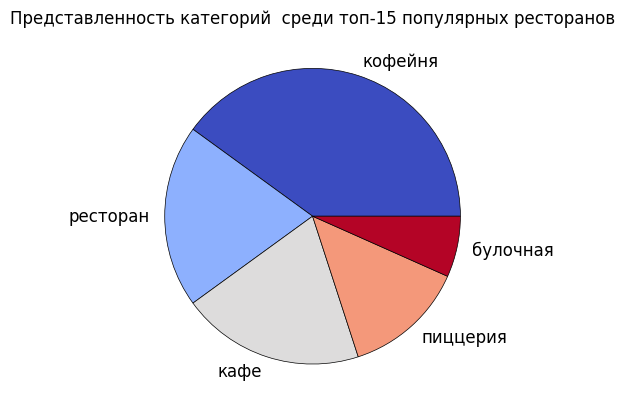

In [111]:
dftop15['category'].value_counts().plot(kind = 'pie', 
                                colormap = 'coolwarm', 
                                label = '',
                                wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
                                textprops={ 'fontsize': 12}
                               )
plt.title('Представленность категорий  среди топ-15 популярных ресторанов')
plt.show()

Среди самых популярных заведений Москвы, большинство - кофейни. Средний рейтинг варьируется от 3.9 ('Яндекс Лавка') до 4.39 ("Кулинарная лавка братьев Караваевых"). Топ-3 самых популярных сетевых кафе  - это 'Шоколадница', 'Домино'c пицца' и 'Додо пицца'.

---

### Вариация среднего чека заведения в зависимости от района Москвы.

In [114]:
print('Средний чек в различных округах Москвы:')
display(df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending = False).round(2))

Средний чек в различных округах Москвы:


district
Центральный административный округ         1191.06
Западный административный округ            1053.23
Северный административный округ             927.96
Южный административный округ                834.40
Северо-Западный административный округ      822.22
Восточный административный округ            820.63
Юго-Западный административный округ         792.56
Северо-Восточный административный округ     716.61
Юго-Восточный административный округ        654.10
Name: middle_avg_bill, dtype: float64

В данных наблюдалось три сильных выброса значений с `middle_avg_bill` >= 10000. Отфильтровала эти значения, т.к. качественно на подсчеты они не влияли, но визуализацию с выбросами портили.

'Медиана значений: '

is_ZAO
ЦАО       1000.0
не ЦАО     600.0
Name: middle_avg_bill, dtype: float64

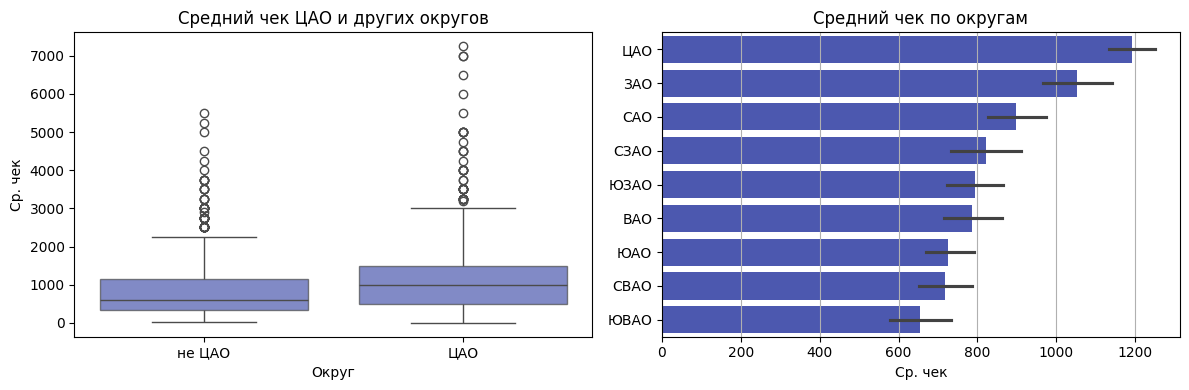

In [116]:
df['is_ZAO'] = df['district'].str.contains('Центральный')
df['is_ZAO'] = df['is_ZAO'].replace({False: 'не ЦАО', True:'ЦАО'})

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
display("Медиана значений: ", df[df['middle_avg_bill']<30000].groupby('is_ZAO')['middle_avg_bill'].median().sort_values(ascending = False).round(2))
sns.boxplot(data = df[df['middle_avg_bill']<10000], x = 'is_ZAO', y = 'middle_avg_bill', ax = axes[0], color = '#3b4cc0', boxprops=dict(alpha=0.7))

order = df[df['middle_avg_bill']<10000].groupby('district_short')['middle_avg_bill'].mean().sort_values(ascending = False).index
sns.barplot(data = df[df['middle_avg_bill']<10000], y = 'district_short', x = 'middle_avg_bill', order = order, ax = axes[1], color = '#3b4cc0')

axes[0].set_title('Средний чек ЦАО и других округов')
axes[1].set_title('Cредний чек по округам')
axes[0].set_xlabel('Округ')
axes[1].set_xlabel('Ср. чек')
axes[0].set_ylabel('Ср. чек')
axes[1].set_ylabel('')
axes[1].grid(axis= 'x')

plt.tight_layout()
plt.show()


Медиана среднего чека в ЦАО составила  1000 руб., во всех остальных областях Москвы - 600 руб. ЦАО является областью с самым большим средним чеком (1191 руб.), на втором месте ЗАО со средним чеком заведений 1053 руб., на третьем месте - САО, средний чек - 927 руб. 

In [118]:
pivot_avbill = pd.pivot_table(df, index = 'category', columns = 'district_short', 
                              values = 'middle_avg_bill',  aggfunc = 'mean', margins = True)
print('Средний чек в разных округах Москвы в разбивке по категориям:')
display(pivot_avbill.style.background_gradient(cmap='coolwarm', axis=1).format("{:.2f}"))

Средний чек в разных округах Москвы в разбивке по категориям:


district_short,ВАО,ЗАО,САО,СВАО,СЗАО,ЦАО,ЮАО,ЮВАО,ЮЗАО,All
category,,,,,,,,,,
"бар,паб",1209.04,1305.56,1572.81,986.91,1057.14,1479.74,1079.11,1043.18,995.53,1338.76
булочная,263.89,723.12,625.00,515.71,200.00,1237.92,458.33,375.00,556.67,658.77
быстрое питание,831.73,432.33,327.13,435.66,295.00,532.08,376.92,479.14,411.32,445.76
кафе,607.94,826.84,723.82,673.70,797.97,765.18,696.53,589.21,594.66,707.75
кофейня,486.11,694.44,495.74,433.16,440.64,794.76,504.78,263.00,381.82,614.21
пиццерия,700.73,905.07,722.62,579.46,682.58,1104.84,662.93,561.60,786.66,789.38
ресторан,1221.46,1478.23,1312.78,1024.57,1235.83,1561.06,1393.33,931.63,1117.36,1367.88
столовая,364.70,565.00,337.50,325.24,298.64,319.89,291.39,288.93,311.67,335.35
All,820.63,1053.23,927.96,716.61,822.22,1191.06,834.40,654.10,792.56,958.05


Самые дорогие столовые в ЗАО, самое дорогое быстрое питание в ВАО, самые дорогие бары в САО, а все остальное самое дорогое - в центре.

---

### Стоимость чашки кофе в зависимости от расположения или типа заведения.

In [124]:
display(df.groupby('district_short')['middle_coffee_cup'].mean().sort_values(ascending = False).round(2))
display(df.groupby('category')['middle_coffee_cup'].mean().sort_values(ascending = False).round(2))

district_short
ЗАО     189.64
ЦАО     188.21
ЮЗАО    183.49
ВАО     174.02
СВАО    165.33
САО     165.09
СЗАО    160.46
ЮАО     157.83
ЮВАО    150.77
Name: middle_coffee_cup, dtype: float64

category
бар,паб            208.33
кофейня            175.06
пиццерия           153.33
быстрое питание    140.00
кафе               105.50
булочная              NaN
ресторан              NaN
столовая              NaN
Name: middle_coffee_cup, dtype: float64

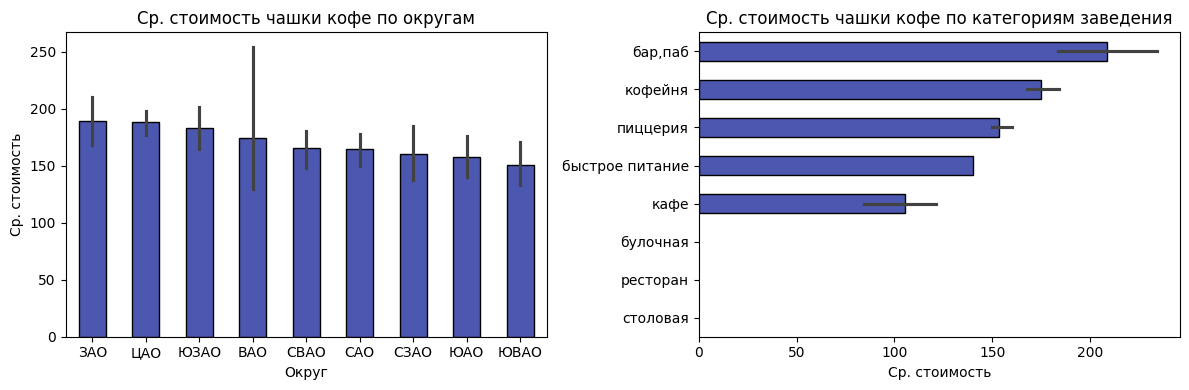

In [125]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

order = df.groupby('district_short')['middle_coffee_cup'].mean().sort_values(ascending = False).index
sns.barplot(data = df, y = 'middle_coffee_cup', x = 'district_short', 
            order = order, ax = axes[0], color = '#3b4cc0', width = 0.5, edgecolor = 'k', estimator = 'mean')

order = df.groupby('category')['middle_coffee_cup'].mean().sort_values(ascending = False).index
sns.barplot(data = df, x = 'middle_coffee_cup', y = 'category', 
            order = order, ax = axes[1], color = '#3b4cc0', width = 0.5, edgecolor = 'k', estimator = 'mean')

axes[0].set_title('Ср. стоимость чашки кофе по округам')
axes[1].set_title('Ср. стоимость чашки кофе по категориям заведения')
axes[0].set_xlabel('Округ')
axes[1].set_xlabel('Ср. стоимость')
axes[0].set_ylabel('Ср. стоимость')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Самая высокая средняя стоимость чашки каппучино оказалась в Западном административном округе (~189 руб). На втором месте по цене - стоимость каппучино в Центральном административном округе. Дешевле всего пить каппучино в ЮАО и ЮВАО.
Как ни странно, дороже всего каппучино стоит в барах, в среднем 208 руб. за чашку. Для булочных, ресторанов и столовых данные по стоимости чашки каппучино отсутствуют. 

---

### Резюме по результатам EDA

- Самые популярные категории заведений Москвы - `кафе` и `рестораны`, самые редкие -  `булочные` и `столовые`
- Больше всего заведений располгаются в центре Москвы, также много заведений на Севере и в Южном округе. Меньше всего заведений расположено в Северо-Западном и Юго-Западном округах.
-  62% заведений являются несетевыми, 38% являются частью сети
-  Чаще всего сетевые заведения встречается среди булочных и пиццерий, однако в асболютных значениях больше всего сетевых кафе и ресторанов, это связано с тем, что больше половины всех завелений Москвы являются кафе или ресторанами.
- В среднем заведения Москвы имеют около 108 посадочных мест, однако встречаются заведения без посадочных мест (быстрое питание) и с количеством мест более 1000.   
- Самый высокий рейтинг имеют бары Москвы (4,39), самый низкий- заведения быстрого питания (4,05)
- Средний рейтинг заведений растет вместе с ростом ценовой категории заведения
- Доля заведений в разных ценовых сегментах зависит от категории заведения, так, среди ресторанов и баров самая большая доля заведений в высоком сегменте и 'выше среднего'. Среди столовых и заведений быстрого питания абсолютное большинство заведений в среднем ценовом сегменте.
- Средний чек заведений в центре Москвы выше ср.чека в остальных округах Москвы почти в 1.5 раза: в среднем в центре посетители тратят 1000р за визит, а посетители кафе в других округах - 600 руб.
- Самый дорогой кофе продается в барах
- Самая высокая средняя цена за чашку каппучино в заведениях Западного Административного округа, она составила почти 190 руб., самая низкая - в заведениях Юго-Восточного округа (150 руб.)

## 4. Итоговый вывод и рекомендации

В рамках исследования рынка общественного питания Москвы был проведен анализ данных о заведениях, включая их категории, расположение, принадлежность к сетям, количество посадочных мест, рейтинги и ценовые сегменты. Основной целью исследования было выявление ключевых закономерностей и особенностей рынка, которые могут быть полезны для принятия решений об инвестировании в заведения общественного питания в Москве.

- Самыми популярными категориями заведений в Москве являются кафе и рестораны, что свидетельствует о высоком спросе на заведения среднего и высокого уровня обслуживания. Наименее распространенными категориями являются булочные и столовые, что может быть связано с изменением предпочтений потребителей в сторону более здоровых и современных форматов питания.

- В целом в Москве наблюдается большая доля заведений в категориях 'выше среднего' и 'высокая', что говорит о наличии платежеспособного покупателя, который ценит качество.

- Больше всего заведений сосредоточено в центре Москвы, а также в Северном и Южном округах.  Наименьшее количество заведений расположено в Северо-Западном и Юго-Западном округах, несмотря на то, что данные округа имеют престижные жилые районы с высокой плотностью и платежеспособное население. Вероятно, стоит провести дополнительный анализ, чтобы выяснить в какие категории заведений могут быть востребованы в этих округах.

- Самый высокий рейтинг имеют бары (4,39), что может быть связано с их популярностью среди молодежи и туристов.
Самый низкий рейтинг у заведений быстрого питания (4,05), что может быть обусловлено более низким качеством обслуживания или ограниченным ассортиментом. Возможно, это свидетельствует о том, что среди заведений быстрого питаний есть недостаток качественных форматов. Стоит отметить и слабую представленность баров в низком ценовом сегменте, и столовых/заведений быстрого питания в других сементах, кроме среднего.

- Средний чек в центре Москвы (1000 рублей) значительно выше, чем в других округах (600 рублей), что  скорее всего связано с более высокой покупательной способностью жителей и высокой проходимостью заведений. 

- Самая высокая средняя цена за чашку капучино наблюдается в Западном административном округе (190 рублей), а самая низкая — в Юго-Восточном округе (150 рублей). Вероятно, распределение среднего чека и стоимости кофе отражает в целом распределение платежеспособности населения, проживающего в этих районах, поэтому при принятии решения о ценовом сегменте заведения, стоит обратить внимание, на то, какие ценовые сегменты и категории заведений наиболее востребованы в  конкретном округе.

- Перспективным кажется расширение сети общественного питания в Северо-Западном округе: в нем слабо представлены заведения, и возможна меньшая конкуренция. При этом средний чек по другим заведениям округа составляет 822 руб, что в целом находится в среднем диапазоне распределения цен по Москве. 